# Modelos Logit y OLS para Base de Corredores


 H2 — Vulnerabilidad MiPyme: Las micro y pequeñas empresas reportan mayor victimización y peor percepción de seguridad que las medianas y grandes en los corredores de obras. 

 H3 — Factores de entorno: La iluminación (P43_1B), la vigilancia en zonas de obra (P43_1G) y la señalización (P43_1A) son los factores más asociados con la percepción de empeoramiento de seguridad.

 H4 — Victimización y percepción: Haber sido víctima de delito asociado a las obras (P44) incrementa significativamente la probabilidad de percibir empeoramiento de seguridad. 
 
 H5 — Heterogeneidad espacial: Existen grupos de tramos del Metro con perfiles de seguridad significativamente diferentes, lo que justifica intervenciones diferenciadas. 
 

In [172]:
# =============================================================================
# 0. CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

DATA_DIR = './datos_limpios'
corredores = pd.read_csv(f'{DATA_DIR}/corredores_limpio.csv')

# 1. Selección de Variables

In [173]:
# =============================================================================
# 1. SELECCIÓN DE VARIABLES
# =============================================================================
cols_p43_1 = [c for c in corredores.columns if c.startswith('P43_1')]
cols_p44   = [c for c in corredores.columns if c.startswith('P44_') and c != 'P44_8']

vars_h3 = ['seguridad_empeoro', 'fue_victima'] + cols_p43_1 + cols_p44 + ['obras_iniciadas', 'sector', 'tamano_empresa', 'tramo', 'P1', 'indice_satisfaccion']

df = corredores[vars_h3].copy()

# Nombres descriptivos (para visualizaciones y reportes)
labels = {
    'seguridad_empeoro'  : 'Percepción de seguridad empeoró',
    'fue_victima'        : 'Fue víctima de algún delito',
    'P43_1A'             : 'Señalización',
    'P43_1B'             : 'Iluminación',
    'P43_1C'             : 'Manejo de Basuras',
    'P43_1D'             : 'Reubicación de estación SITP o Transmilenio',
    'P43_1E'             : 'Espacios adecuados para transitar',
    'P43_1F'             : 'Presencia de habitantes de calle',
    'P43_1G'             : 'Vigilancia en zonas de obra',
    'P44_1'              : 'Hurto a comercio',
    'P44_2'              : 'Hurto a personas',
    'P44_3'              : 'Extorsión',
    'P44_4'              : 'Acoso sexual callejero',
    'P44_5'              : 'Violencia de género física y sexual',
    'P44_6'              : 'Lesiones personales',
    'P44_7'              : 'Situaciones de convivencia (intimidación, amenaza y riñas)',
    'obras_iniciadas'    : 'Obras iniciadas en el tramo',
    'sector'             : 'Sector productivo',
    'tamano_empresa'     : 'Tamaño empresa',
    'tramo'              : 'Tramo geográfico',
    'P1'                 : 'Número de empleados',
    'indice_satisfaccion': 'Índice de satisfacción con el entorno',
}

print(f"Dimensiones: {df.shape}")
print(f"\nVariables y descripciones:")
for col in df.columns:
    print(f"  {col:<20} → {labels.get(col, '—')}")
df.head()

Dimensiones: (2105, 22)

Variables y descripciones:
  seguridad_empeoro    → Percepción de seguridad empeoró
  fue_victima          → Fue víctima de algún delito
  P43_1A               → Señalización
  P43_1B               → Iluminación
  P43_1C               → Manejo de Basuras
  P43_1D               → Reubicación de estación SITP o Transmilenio
  P43_1E               → Espacios adecuados para transitar
  P43_1F               → Presencia de habitantes de calle
  P43_1G               → Vigilancia en zonas de obra
  P44_1                → Hurto a comercio
  P44_2                → Hurto a personas
  P44_3                → Extorsión
  P44_4                → Acoso sexual callejero
  P44_5                → Violencia de género física y sexual
  P44_6                → Lesiones personales
  P44_7                → Situaciones de convivencia (intimidación, amenaza y riñas)
  obras_iniciadas      → Obras iniciadas en el tramo
  sector               → Sector productivo
  tamano_empresa       → Tam

,seguridad_empeoro,fue_victima,P43_1A,P43_1B,P43_1C,P43_1D,P43_1E,P43_1F,P43_1G,P44_1,P44_2,P44_3,P44_4,P44_5,P44_6,P44_7,obras_iniciadas,sector,tamano_empresa,tramo,P1,indice_satisfaccion
0,1,1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0,1,0,0,0,0,0,0,Servicio,Grande,18,3.0,3.250000
1,0,1,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1,0,0,0,0,0,0,0,NaN,Pequeña,18,1.0,1.500000
2,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,Servicio,Grande,18,1.0,1.000000
3,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,Comercio,Micro,18,5.0,2.833333
4,0,0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0,0,0,0,0,0,0,0,Servicio,Micro,18,4.0,2.333333


# 2. One Hot Encoding

Realizamos el proceso a las categóricas: sector, tamano_empresa y tramo

In [174]:
# =============================================================================
# 2. ONE HOT ENCODING
# =============================================================================

df_encoded = df.copy()

# --- sector: OHE eliminando 'Comercio' como categoría de referencia ---
df_encoded['sector'] = df_encoded['sector'].replace('NS/NR', np.nan)
ohe_sector = pd.get_dummies(df_encoded['sector'], prefix='sector', dummy_na=False)
ohe_sector = ohe_sector.drop(columns=['sector_Comercio'], errors='ignore')

# --- tamano_empresa: OHE eliminando 'Micro' como categoría de referencia ---
df_encoded['tamano_empresa'] = df_encoded['tamano_empresa'].replace('NS/NR', np.nan)
ohe_tamano = pd.get_dummies(df_encoded['tamano_empresa'], prefix='tamano_empresa', dummy_na=False)
ohe_tamano = ohe_tamano.drop(columns=['tamano_empresa_Micro'], errors='ignore')

# --- tramo: OHE eliminando tramo 1 como categoría de referencia ---
ohe_tramo = pd.get_dummies(df_encoded['tramo'], prefix='tramo', dummy_na=False)
ohe_tramo = ohe_tramo.drop(columns=['tramo_1'], errors='ignore')

# Reemplazar columnas originales por sus dummies
df_encoded = pd.concat([
    df_encoded.drop(columns=['sector', 'tamano_empresa', 'tramo']),
    ohe_sector,
    ohe_tamano,
    ohe_tramo
], axis=1)

print("One Hot Encoding completado — k-1 variables por categoría:")
print(f"  sector        : {list(ohe_sector.columns)}")
print(f"  tamano_empresa: {list(ohe_tamano.columns)}")
print(f"  tramo         : {list(ohe_tramo.columns[:5])} ... ({ohe_tramo.shape[1]} dummies)")
print(f"\nDimensiones finales: {df_encoded.shape}")
df_encoded.head()

One Hot Encoding completado — k-1 variables por categoría:
  sector        : ['sector_Industria', 'sector_Servicio']
  tamano_empresa: ['tamano_empresa_Grande', 'tamano_empresa_Mediana', 'tamano_empresa_Pequeña']
  tramo         : ['tramo_2', 'tramo_3', 'tramo_4', 'tramo_5', 'tramo_6'] ... (18 dummies)

Dimensiones finales: (2105, 42)


,seguridad_empeoro,fue_victima,P43_1A,P43_1B,P43_1C,P43_1D,P43_1E,P43_1F,P43_1G,P44_1,P44_2,P44_3,P44_4,P44_5,P44_6,P44_7,obras_iniciadas,P1,indice_satisfaccion,sector_Industria,sector_Servicio,tamano_empresa_Grande,tamano_empresa_Mediana,tamano_empresa_Pequeña,tramo_2,tramo_3,tramo_4,tramo_5,tramo_6,tramo_7,tramo_8,tramo_9,tramo_10,tramo_11,tramo_12,tramo_13,tramo_14,tramo_15,tramo_16,tramo_17,tramo_18,tramo_19
0,1,1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0,1,0,0,0,0,0,0,3.0,3.250000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,1,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1,0,0,0,0,0,0,0,1.0,1.500000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,1.000000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,5.0,2.833333,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0,0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0,0,0,0,0,0,0,0,4.0,2.333333,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


# 3. Manejo de Valores Nulos

In [175]:
# =============================================================================
# 3. REPORTE DE MISSINGS
# =============================================================================

missings = df_encoded.isnull().sum()
missings = missings[missings > 0].sort_values(ascending=False)

total_filas = len(df_encoded)
filas_con_missing = df_encoded.isnull().any(axis=1).sum()

reporte = pd.DataFrame({
    'Missings':    missings,
    'Porcentaje':  (missings / total_filas * 100).round(2)
})

print(f"Total filas: {total_filas}")
print(f"Filas con al menos un missing: {filas_con_missing} ({filas_con_missing / total_filas * 100:.2f}%)")
print(f"Columnas con missings: {len(reporte)} de {df_encoded.shape[1]}\n")
print(reporte.to_string())

Total filas: 2105
Filas con al menos un missing: 84 (3.99%)
Columnas con missings: 8 de 42

        Missings  Porcentaje
P43_1A        62        2.95
P43_1B        62        2.95
P43_1C        62        2.95
P43_1D        62        2.95
P43_1E        62        2.95
P43_1F        62        2.95
P43_1G        62        2.95
P1            23        1.09


In [176]:
# Eliminamos los missings
df_encoded = df_encoded.dropna()
print(f"Filas eliminadas: {2105 - len(df_encoded)}")
print(f"Filas restantes:  {len(df_encoded)}")
df_encoded

Filas eliminadas: 84
Filas restantes:  2021


,seguridad_empeoro,fue_victima,P43_1A,P43_1B,P43_1C,P43_1D,P43_1E,P43_1F,P43_1G,P44_1,P44_2,P44_3,P44_4,P44_5,P44_6,P44_7,obras_iniciadas,P1,indice_satisfaccion,sector_Industria,sector_Servicio,tamano_empresa_Grande,tamano_empresa_Mediana,tamano_empresa_Pequeña,tramo_2,tramo_3,tramo_4,tramo_5,tramo_6,tramo_7,tramo_8,tramo_9,tramo_10,tramo_11,tramo_12,tramo_13,tramo_14,tramo_15,tramo_16,tramo_17,tramo_18,tramo_19
0,1,1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0,1,0,0,0,0,0,0,3.0,3.250000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,1,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1,0,0,0,0,0,0,0,1.0,1.500000,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,1.0,1.000000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,5.0,2.833333,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0,0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0,0,0,0,0,0,0,0,4.0,2.333333,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,1,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0,0,0,0,0,0,1,1.0,1.000000,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
2101,1,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0,0,0,0,0,0,0,1,4.0,2.500000,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2102,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1,0,1,1,1,0,1,1.0,1.666667,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2103,0,1,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1,1,0,0,0,1,0,1,1.0,2.250000,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


# 4. Regresión Logística — Variable Dependiente Empeoramiento de la Percepción de Inseguridad

In [177]:
# =============================================================================
# 4. REGRESIÓN LOGÍSTICA — INFERENCIA CAUSAL (sin variables de tramo)
# =============================================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Función para renombrar columnas usando labels ---
def renombrar(col):
    if col in labels:
        return labels[col]
    for prefix, base in [('sector_', 'sector'), ('tamano_empresa_', 'tamano_empresa'), ('tramo_', 'tramo')]:
        if col.startswith(prefix):
            return f"{labels.get(base, base)}: {col[len(prefix):]}"
    return col

# --- Separar variable dependiente y regresores ---
y = df_encoded['seguridad_empeoro']
X = df_encoded.drop(columns=['seguridad_empeoro']).astype(int)

# Eliminar dummies de tramo
cols_tramo = [c for c in X.columns if c.startswith('tramo_')]
X1 = X.drop(columns=cols_tramo).rename(columns=renombrar)

X1_const = sm.add_constant(X1)

# --- Estimación Logit con errores robustos HC1 ---
modelo_logit = Logit(y, X1_const).fit(cov_type='HC1', disp=False)
print(modelo_logit.summary())

# --- Odds Ratios con IC 95% ---
or_tabla = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit.params),
    'IC 2.5%':    np.exp(modelo_logit.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit.conf_int()[1]),
    'p-valor':    modelo_logit.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro) ---")
print(or_tabla.round(4).to_string())

# --- Verificación de multicolinealidad (VIF) ---
vif = pd.DataFrame({
    'Variable': X1_const.columns,
    'VIF': [variance_inflation_factor(X1_const.values, i)
            for i in range(X1_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:      seguridad_empeoro   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     1997
Method:                           MLE   Df Model:                           23
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.1016
Time:                        23:21:23   Log-Likelihood:                -1251.2
converged:                       True   LL-Null:                       -1392.7
Covariance Type:                  HC1   LLR p-value:                 1.181e-46
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                                          0.3420      0.204      1.674      0.094      -0.058

In [178]:
# =============================================================================
# 4B. REGRESIÓN LOGÍSTICA SIN obras_iniciadas
# =============================================================================

X2 = X.drop(columns=['obras_iniciadas']).rename(columns=renombrar)
X2_const = sm.add_constant(X2)

modelo_logit_2 = Logit(y, X2_const).fit(cov_type='HC1', disp=False)
print(modelo_logit_2.summary())

# --- Odds Ratios con IC 95% ---
or_tabla_2 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit_2.params),
    'IC 2.5%':    np.exp(modelo_logit_2.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit_2.conf_int()[1]),
    'p-valor':    modelo_logit_2.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro | Tramo 1) ---")
print(or_tabla_2.round(4).to_string())

# --- Verificación de multicolinealidad (VIF) ---
vif_2 = pd.DataFrame({
    'Variable': X2_const.columns,
    'VIF': [variance_inflation_factor(X2_const.values, i)
            for i in range(X2_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_2.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:      seguridad_empeoro   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     1980
Method:                           MLE   Df Model:                           40
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.1213
Time:                        23:21:23   Log-Likelihood:                -1223.8
converged:                       True   LL-Null:                       -1392.7
Covariance Type:                  HC1   LLR p-value:                 8.212e-49
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                                         -0.5526      0.340     -1.627      0.104      -1.218

# 5. Regresión Logística — Variable Dependiente: Fue Víctima de Algún Delito

In [179]:
# =============================================================================
# 5A. REGRESIÓN LOGÍSTICA — P(Fue víctima) = f(X), sin dummies de tramo
# =============================================================================

# Variable dependiente
y_v = df_encoded['fue_victima']

# Regresores: todo excepto las dos vars dependientes y las P44_*
cols_p44 = [c for c in df_encoded.columns if c.startswith('P44_')]
cols_excluir_5a = ['seguridad_empeoro', 'fue_victima'] + cols_p44
cols_tramo = [c for c in df_encoded.columns if c.startswith('tramo_')]

X_v = df_encoded.drop(columns=cols_excluir_5a).astype(int)
X_v1 = X_v.drop(columns=cols_tramo).rename(columns=renombrar)
X_v1_const = sm.add_constant(X_v1)

# --- Estimación Logit con errores robustos HC1 ---
modelo_logit_v1 = Logit(y_v, X_v1_const).fit(cov_type='HC1', disp=False)
print(modelo_logit_v1.summary())

# --- Odds Ratios con IC 95% ---
or_v1 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit_v1.params),
    'IC 2.5%':    np.exp(modelo_logit_v1.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit_v1.conf_int()[1]),
    'p-valor':    modelo_logit_v1.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro) ---")
print(or_v1.round(4).to_string())

# --- VIF ---
vif_v1 = pd.DataFrame({
    'Variable': X_v1_const.columns,
    'VIF': [variance_inflation_factor(X_v1_const.values, i)
            for i in range(X_v1_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_v1.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:            fue_victima   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     2005
Method:                           MLE   Df Model:                           15
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                 0.02572
Time:                        23:21:23   Log-Likelihood:                -1321.4
converged:                       True   LL-Null:                       -1356.3
Covariance Type:                  HC1   LLR p-value:                 4.913e-09
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                           0.1095      0.193      0.566      0.571      -0.270       0.489
Señalización                    

In [180]:
# =============================================================================
# 5B. REGRESIÓN LOGÍSTICA — P(Fue víctima) = f(X), con dummies de tramo
# =============================================================================

cols_excluir_5b = ['seguridad_empeoro', 'fue_victima', 'obras_iniciadas'] + cols_p44

X_v2 = df_encoded.drop(columns=cols_excluir_5b).astype(int).rename(columns=renombrar)
X_v2_const = sm.add_constant(X_v2)

# --- Estimación Logit con errores robustos HC1 ---
modelo_logit_v2 = Logit(y_v, X_v2_const).fit(cov_type='HC1', disp=False)
print(modelo_logit_v2.summary())

# --- Odds Ratios con IC 95% ---
or_v2 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_logit_v2.params),
    'IC 2.5%':    np.exp(modelo_logit_v2.conf_int()[0]),
    'IC 97.5%':   np.exp(modelo_logit_v2.conf_int()[1]),
    'p-valor':    modelo_logit_v2.pvalues
}).drop(index='const').sort_values('p-valor')

print("\n--- Odds Ratios (referencia: Comercio | Micro | Tramo 1) ---")
print(or_v2.round(4).to_string())

# --- VIF ---
vif_v2 = pd.DataFrame({
    'Variable': X_v2_const.columns,
    'VIF': [variance_inflation_factor(X_v2_const.values, i)
            for i in range(X_v2_const.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("\n--- Factor de Inflación de Varianza (VIF) ---")
print(vif_v2.to_string(index=False))
print("\nNota: VIF > 10 indica multicolinealidad problemática.")

                           Logit Regression Results                           
Dep. Variable:            fue_victima   No. Observations:                 2021
Model:                          Logit   Df Residuals:                     1988
Method:                           MLE   Df Model:                           32
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                 0.04417
Time:                        23:21:23   Log-Likelihood:                -1296.3
converged:                       True   LL-Null:                       -1356.3
Covariance Type:                  HC1   LLR p-value:                 4.465e-12
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                           0.2635      0.318      0.828      0.408      -0.360       0.887
Señalización                    

# 6. Modelo OLS

In [181]:
# =============================================================================
# 7A. OLS (LPM) CON ERRORES ROBUSTOS — Seguridad empeoró, sin dummies de tramo
# =============================================================================
# seguridad_empeoro = β₀ + β₁·fue_victima + β₂·obras_iniciadas
#                   + β₃·indice_satisfaccion + β₄·P43_1* (factores entorno)
#                   + β₅·tamano_empresa_* + β₆·sector_* + ε

y_ols  = df_encoded['seguridad_empeoro']
X_base = df_encoded.drop(columns=['seguridad_empeoro']).astype(int)

cols_tramo = [c for c in X_base.columns if c.startswith('tramo_')]
X_ols1 = X_base.drop(columns=cols_tramo).rename(columns=renombrar)
X_ols1_const = sm.add_constant(X_ols1)

ols1 = sm.OLS(y_ols, X_ols1_const).fit(cov_type='HC1')
print(ols1.summary())

# --- Tabla de coeficientes ordenada por p-valor ---
coef1 = pd.DataFrame({
    'Coeficiente': ols1.params,
    'Error std.':  ols1.bse,
    'IC 2.5%':     ols1.conf_int()[0],
    'IC 97.5%':    ols1.conf_int()[1],
    'p-valor':     ols1.pvalues,
}).drop(index='const').sort_values('p-valor')

print("\n--- Coeficientes ordenados por p-valor (referencia: Comercio | Micro) ---")
print(coef1.round(4).to_string())
print(f"\nR² = {ols1.rsquared:.4f} | R² ajustado = {ols1.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:      seguridad_empeoro   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     17.69
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           9.26e-65
Time:                        23:21:23   Log-Likelihood:                -1317.3
No. Observations:                2021   AIC:                             2683.
Df Residuals:                    1997   BIC:                             2817.
Df Model:                          23                                         
Covariance Type:                  HC1                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [182]:
# =============================================================================
# 7B. OLS (LPM) CON ERRORES ROBUSTOS — Seguridad empeoró, con dummies de tramo
# =============================================================================

X_ols2 = X_base.drop(columns=['obras_iniciadas']).rename(columns=renombrar)
X_ols2_const = sm.add_constant(X_ols2)

ols2 = sm.OLS(y_ols, X_ols2_const).fit(cov_type='HC1')
print(ols2.summary())

# --- Tabla de coeficientes ordenada por p-valor ---
coef2 = pd.DataFrame({
    'Coeficiente': ols2.params,
    'Error std.':  ols2.bse,
    'IC 2.5%':     ols2.conf_int()[0],
    'IC 97.5%':    ols2.conf_int()[1],
    'p-valor':     ols2.pvalues,
}).drop(index='const').sort_values('p-valor')

print("\n--- Coeficientes ordenados por p-valor (referencia: Comercio | Micro | Tramo 1) ---")
print(coef2.round(4).to_string())
print(f"\nR² = {ols2.rsquared:.4f} | R² ajustado = {ols2.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:      seguridad_empeoro   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     13.02
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           3.79e-74
Time:                        23:21:23   Log-Likelihood:                -1289.3
No. Observations:                2021   AIC:                             2661.
Df Residuals:                    1980   BIC:                             2891.
Df Model:                          40                                         
Covariance Type:                  HC1                                         
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

# Clustering

In [183]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42

# Base limpia sin missings
df_clean = df.dropna().copy()

# Guardar variables categóricas para comparar con la segmentación después
meta_corr = df_clean[['sector', 'tamano_empresa', 'tramo']].copy()
meta_corr['corredor_nombre'] = corredores.loc[df_clean.index, 'corredor_nombre'].values

# df de clustering: solo variables numéricas
df_clustering_corr = df_clean.drop(columns=['sector', 'tamano_empresa', 'tramo']).copy()

# Estandarizar P1 e indice_satisfaccion (escala muy distinta al resto)
scaler = StandardScaler()
df_clustering_corr[['P1', 'indice_satisfaccion']] = scaler.fit_transform(
    df_clustering_corr[['P1', 'indice_satisfaccion']]
)

print(f"Filas tras dropna: {len(df_clean)}")
print(f"Dimensiones df_clustering_corr: {df_clustering_corr.shape}")
print(f"Variables: {list(df_clustering_corr.columns)}")

Filas tras dropna: 1991
Dimensiones df_clustering_corr: (1991, 19)
Variables: ['seguridad_empeoro', 'fue_victima', 'P43_1A', 'P43_1B', 'P43_1C', 'P43_1D', 'P43_1E', 'P43_1F', 'P43_1G', 'P44_1', 'P44_2', 'P44_3', 'P44_4', 'P44_5', 'P44_6', 'P44_7', 'obras_iniciadas', 'P1', 'indice_satisfaccion']


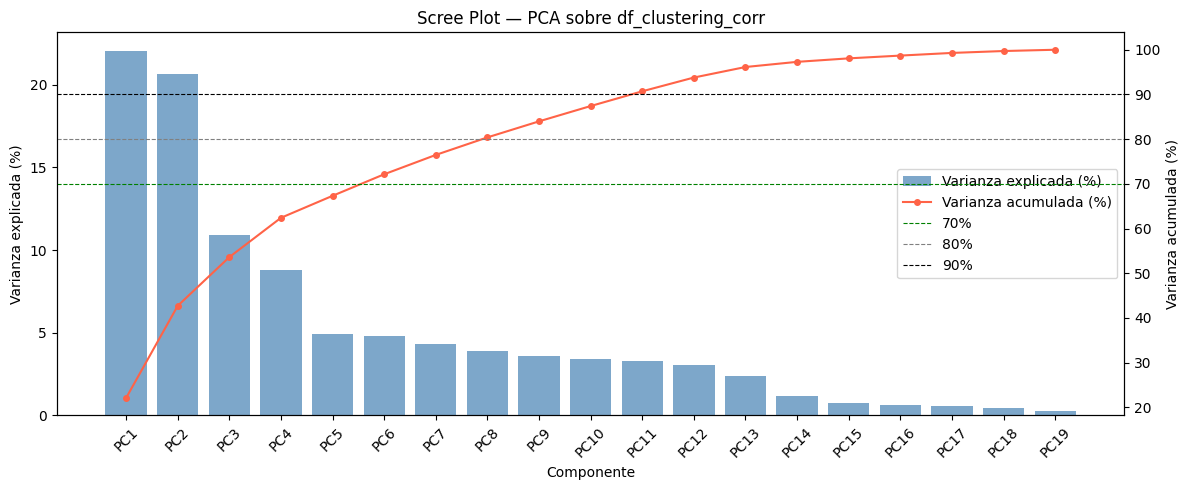

Componentes para 70% de varianza: 6
Componentes para 80% de varianza: 8
Componentes para 90% de varianza: 11
Varianza explicada por los primeros 10 componentes: 87.40%


In [184]:
# PCA con todas las componentes
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(df_clustering_corr)

var_exp  = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(var_exp)
comp_labels = [f"PC{i+1}" for i in range(len(var_exp))]

# Scree plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(comp_labels, var_exp * 100, color='steelblue', alpha=0.7, label='Varianza explicada (%)')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_xlabel('Componente')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(comp_labels, cum_var * 100, color='tomato', marker='o', markersize=4, label='Varianza acumulada (%)')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.axhline(70, color='green', linestyle='--', linewidth=0.8, label='70%')
ax2.axhline(80, color='gray',  linestyle='--', linewidth=0.8, label='80%')
ax2.axhline(90, color='black', linestyle='--', linewidth=0.8, label='90%')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Scree Plot — PCA sobre df_clustering_corr')
plt.tight_layout()
plt.show()

n_70 = int(np.argmax(cum_var >= 0.70)) + 1
n_80 = int(np.argmax(cum_var >= 0.80)) + 1
n_90 = int(np.argmax(cum_var >= 0.90)) + 1
print(f"Componentes para 70% de varianza: {n_70}")
print(f"Componentes para 80% de varianza: {n_80}")
print(f"Componentes para 90% de varianza: {n_90}")
print(f"Varianza explicada por los primeros 10 componentes: {cum_var[9]*100:.2f}%")

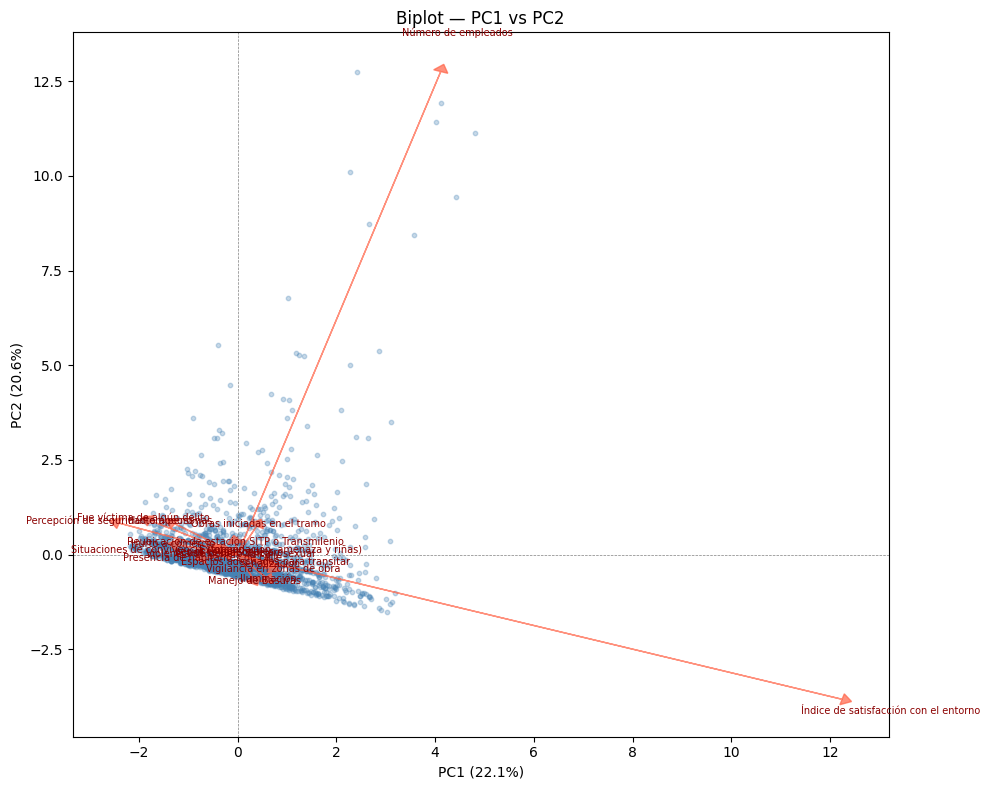

In [185]:
# Biplot PC1 vs PC2
scores    = pca_full.transform(df_clustering_corr)
loadings  = pca_full.components_[:2].T
feature_names = [labels.get(c, c) for c in df_clustering_corr.columns]

scale = np.max(np.abs(scores[:, :2])) / np.max(np.abs(loadings))

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=10, color='steelblue')

for i, var in enumerate(feature_names):
    ax.arrow(0, 0,
             loadings[i, 0] * scale, loadings[i, 1] * scale,
             head_width=0.3, head_length=0.2,
             fc='tomato', ec='tomato', alpha=0.7)
    ax.text(loadings[i, 0] * scale * 1.08,
            loadings[i, 1] * scale * 1.08,
            var, fontsize=7, ha='center', va='center', color='darkred')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Biplot — PC1 vs PC2')
plt.tight_layout()
plt.show()

In [186]:
# Loadings PC1 y PC2
loadings_df = pd.DataFrame(
    pca_full.components_[:2].T,
    index=[labels.get(c, c) for c in df_clustering_corr.columns],
    columns=['PC1', 'PC2']
).sort_values('PC1', key=abs, ascending=False)

print(loadings_df.to_string())

                                                                 PC1       PC2
Índice de satisfacción con el entorno                       0.909493 -0.283821
Número de empleados                                         0.305643  0.947592
Percepción de seguridad empeoró                            -0.178141  0.061781
Fue víctima de algún delito                                -0.130864  0.066356
Hurto a personas                                           -0.094583  0.060510
Hurto a comercio                                           -0.089827  0.018943
Vigilancia en zonas de obra                                 0.049783 -0.025290
Presencia de habitantes de calle                           -0.048839 -0.006194
Señalización                                                0.044825 -0.017604
Iluminación                                                 0.042532 -0.044843
Espacios adecuados para transitar                           0.038847 -0.013674
Situaciones de convivencia (intimidación, amenaza y 

In [187]:
scores = pca_full.transform(df_clustering_corr)
X_pca  = scores[:, :10]

# Selección del K óptimo por Silhouette
K_RANGE = range(2, 13)
results = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    results.append({
        "k":                 k,
        "inertia":           km.inertia_,
        "silhouette":        silhouette_score(X_pca, labels, sample_size=500, random_state=RANDOM_STATE),
        "davies_bouldin":    davies_bouldin_score(X_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
    })

res = pd.DataFrame(results)
print(res.round(4).to_string(index=False))

k_opt = int(res.loc[res["silhouette"].idxmax(), "k"])
print(f"\nK óptimo (Silhouette máximo): k = {k_opt}"
      f"  →  sil = {res['silhouette'].max():.4f}"
      f"  |  db = {res.loc[res['silhouette'].idxmax(), 'davies_bouldin']:.4f}"
      f"  |  ch = {res.loc[res['silhouette'].idxmax(), 'calinski_harabasz']:.1f}")

 k   inertia  silhouette  davies_bouldin  calinski_harabasz
 2 7051.1739      0.1690          2.0783           389.1027
 3 5915.8178      0.1693          1.5749           422.5437
 4 5393.1827      0.1470          1.8036           373.0195
 5 5018.5157      0.1357          1.7601           337.5669
 6 4658.7815      0.1353          1.5753           321.4145
 7 4404.4424      0.1306          1.6274           302.2665
 8 4200.4933      0.1264          1.6574           285.2824
 9 4038.1417      0.1092          1.7192           269.4863
10 3905.3414      0.1070          1.7398           255.0489
11 3788.7604      0.1106          1.7430           242.5802
12 3698.4728      0.1035          1.7965           230.1889

K óptimo (Silhouette máximo): k = 3  →  sil = 0.1693  |  db = 1.5749  |  ch = 422.5


In [188]:
from sklearn.metrics import silhouette_samples

def evaluate_clustering(X, labels, method_name):
    n_clusters = len(set(labels) - {-1})
    n_noise    = (labels == -1).sum()
    mask       = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan
    return {
        "method":     method_name,
        "n_clusters": n_clusters,
        "n_noise":    int(n_noise),
        "silhouette": round(float(sil), 4) if not np.isnan(sil) else np.nan,
    }

# Modelo K-Means final
km_final  = KMeans(n_clusters=k_opt, n_init=20, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_pca)
print(evaluate_clustering(X_pca, labels_km, f"K-Means (k={k_opt})"))

{'method': 'K-Means (k=3)', 'n_clusters': 3, 'n_noise': 0, 'silhouette': 0.1701}


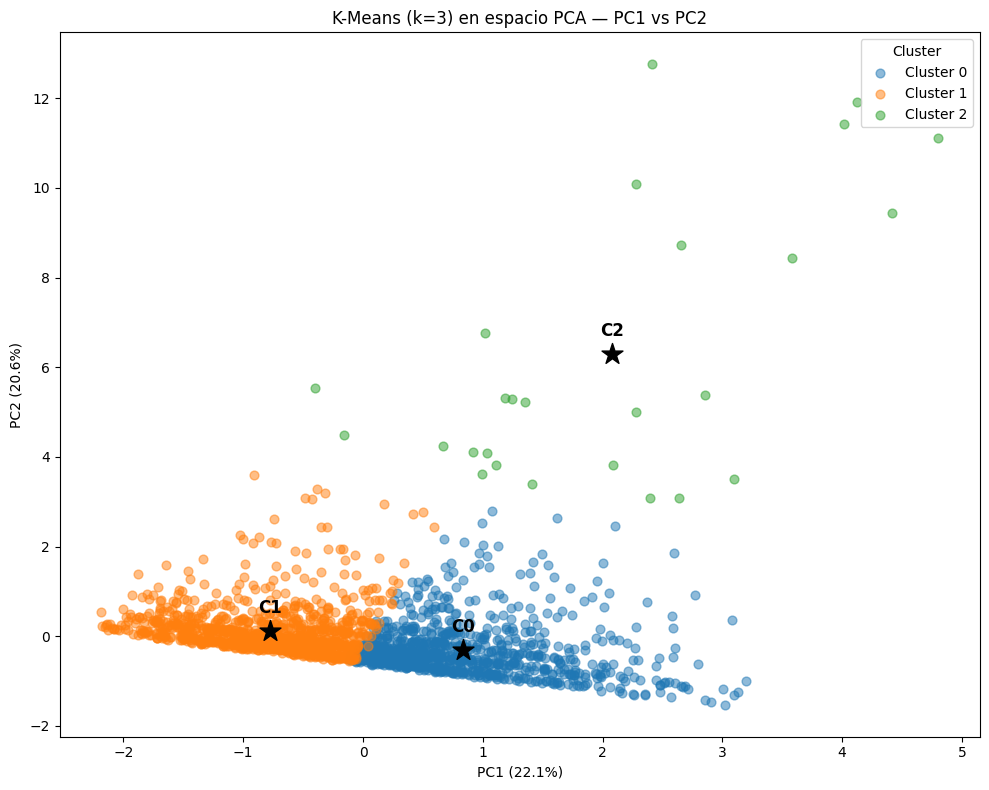

In [189]:
# Scatter K-Means en espacio PCA (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 8))

for seg in sorted(np.unique(labels_km)):
    mask = labels_km == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=40, label=f"Cluster {seg}")
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, marker="*", s=250, c="black", zorder=5)
    ax.annotate(f"C{seg}", (cx, cy), fontsize=12, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 10), textcoords="offset points")

ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
ax.set_title(f"K-Means (k={k_opt}) en espacio PCA — PC1 vs PC2")
ax.legend(title="Cluster", loc="best")
plt.tight_layout()
plt.show()

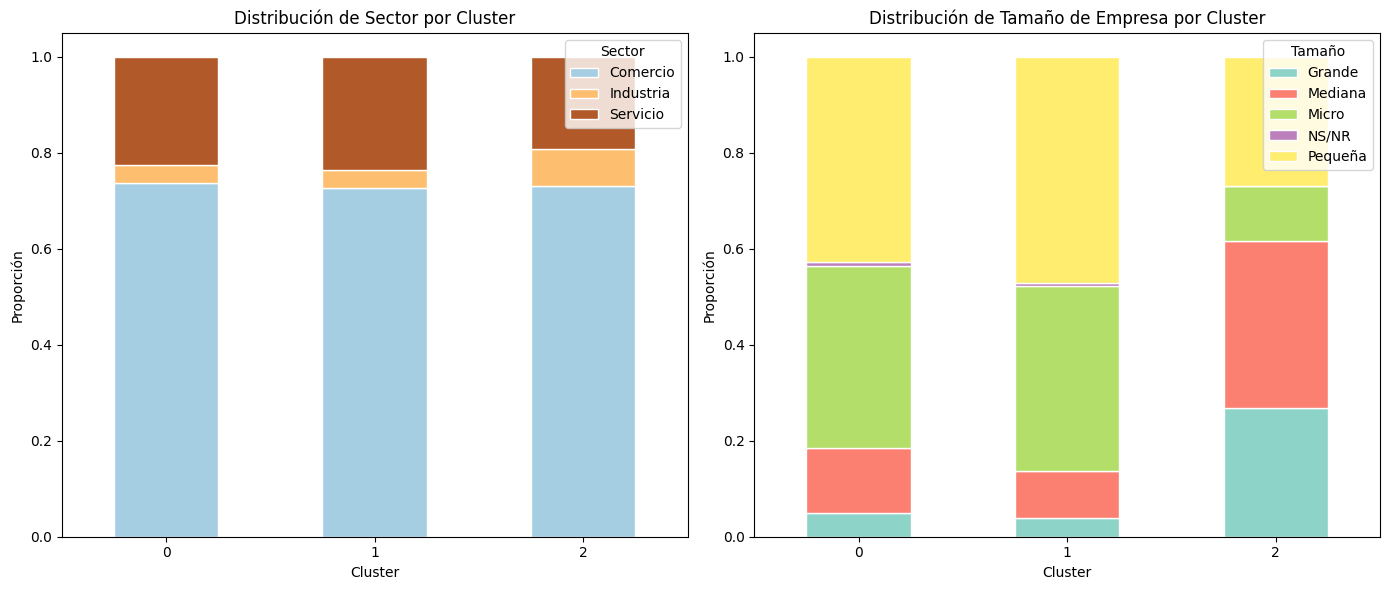

Distribución de Tramo por Cluster (proporciones):
tramo       1      2      3      4      5      6      7      8      9      10     11     12     13     14     15     16     17     18     19
Cluster                                                                                                                                     
0        0.036  0.026  0.022  0.022  0.030  0.037  0.023  0.013  0.024  0.033  0.038  0.038  0.038  0.048  0.023  0.022  0.133  0.030  0.364
1        0.029  0.046  0.046  0.043  0.053  0.029  0.043  0.060  0.044  0.035  0.037  0.032  0.031  0.027  0.049  0.049  0.096  0.012  0.240
2        0.038  0.000  0.038  0.000  0.000  0.038  0.038  0.077  0.000  0.038  0.000  0.000  0.038  0.038  0.077  0.077  0.000  0.000  0.500


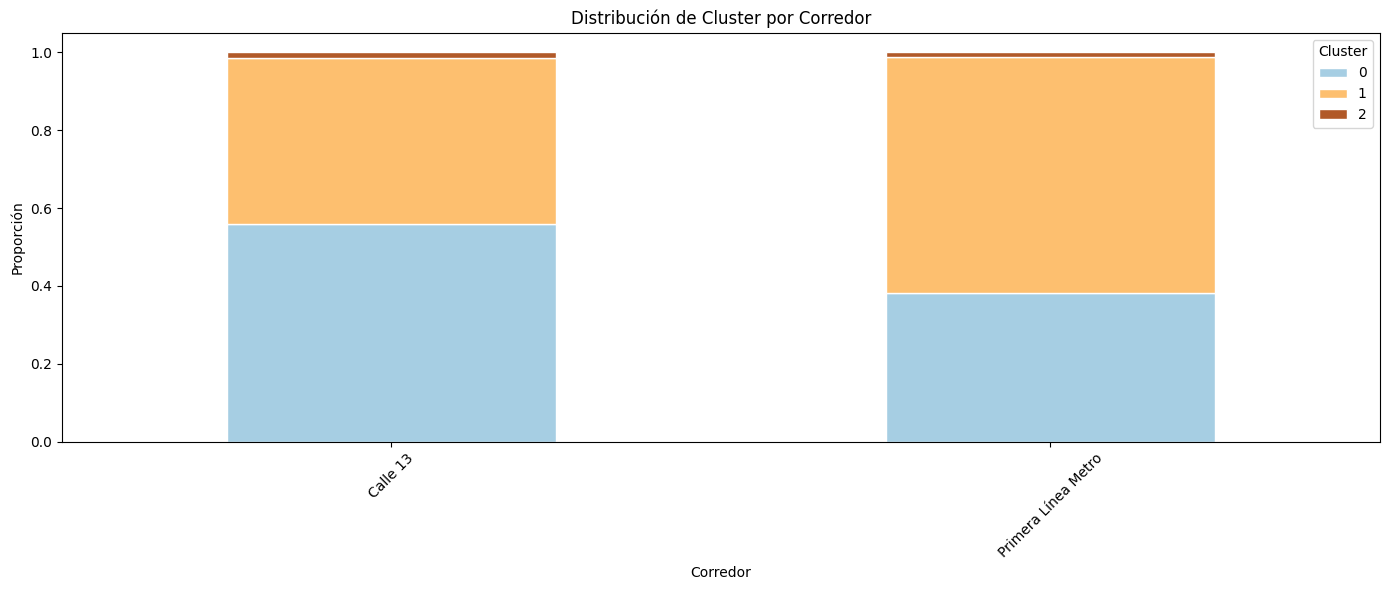

In [190]:
# Composición de variables categóricas por cluster
df_segmented_corr = meta_corr.copy()
df_segmented_corr["Cluster"] = labels_km

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sector
ct_sector = pd.crosstab(df_segmented_corr["Cluster"], df_segmented_corr["sector"], normalize="index")
ct_sector.plot(kind="bar", stacked=True, ax=axes[0], colormap="Paired", edgecolor="white")
axes[0].set_title("Distribución de Sector por Cluster")
axes[0].set_ylabel("Proporción")
axes[0].set_xlabel("Cluster")
axes[0].legend(title="Sector")
axes[0].tick_params(axis="x", rotation=0)

# Tamaño de empresa
ct_tamano = pd.crosstab(df_segmented_corr["Cluster"], df_segmented_corr["tamano_empresa"], normalize="index")
ct_tamano.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3", edgecolor="white")
axes[1].set_title("Distribución de Tamaño de Empresa por Cluster")
axes[1].set_ylabel("Proporción")
axes[1].set_xlabel("Cluster")
axes[1].legend(title="Tamaño")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Distribución de tramo por cluster (tabla)
ct_tramo = pd.crosstab(df_segmented_corr["Cluster"], df_segmented_corr["tramo"], normalize="index").round(3)
print("Distribución de Tramo por Cluster (proporciones):")
print(ct_tramo.to_string())

# Distribución de corredor_nombre por cluster
fig, ax = plt.subplots(figsize=(14, 6))
ct_corredor = pd.crosstab(df_segmented_corr["corredor_nombre"], df_segmented_corr["Cluster"], normalize="index")
ct_corredor.plot(kind="bar", stacked=True, ax=ax, colormap="Paired", edgecolor="white")
ax.set_title("Distribución de Cluster por Corredor")
ax.set_ylabel("Proporción")
ax.set_xlabel("Corredor")
ax.legend(title="Cluster")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

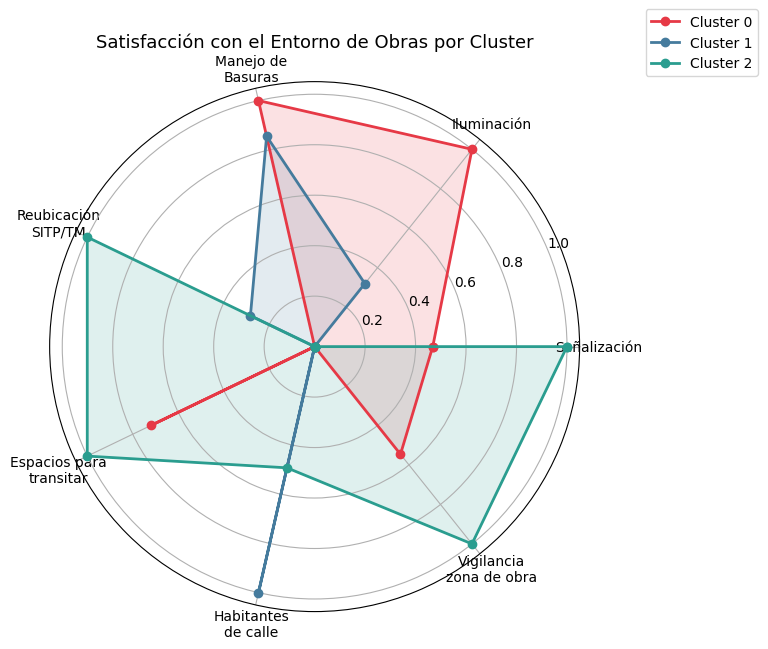

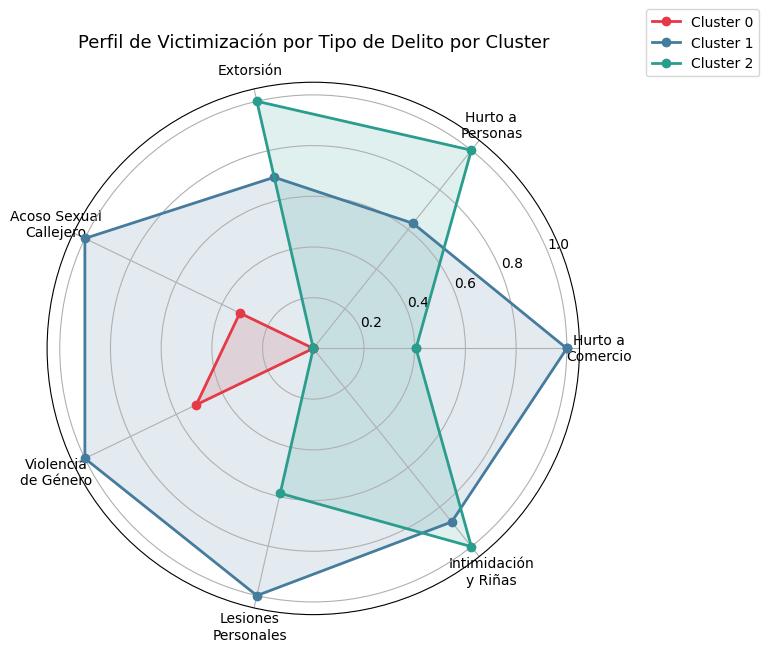

In [191]:
RADAR_COLORS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#6A4C93", "#43AA8B", "#F3722C"]

df_radar_corr = df_clustering_corr.copy()
df_radar_corr["Cluster"] = labels_km

# ── Radar 1: Satisfacción con el entorno de obras (P43_1A-G) ─────────────────
ENTORNO_OBRAS_VARS = {
    "P43_1A": "Señalización",
    "P43_1B": "Iluminación",
    "P43_1C": "Manejo de\nBasuras",
    "P43_1D": "Reubicación\nSITP/TM",
    "P43_1E": "Espacios para\ntransitar",
    "P43_1F": "Habitantes\nde calle",
    "P43_1G": "Vigilancia\nzona de obra",
}

seg_prof1 = df_radar_corr.groupby("Cluster")[list(ENTORNO_OBRAS_VARS.keys())].mean()
prof_norm1 = seg_prof1.copy()
for col in ENTORNO_OBRAS_VARS:
    mn, mx = seg_prof1[col].min(), seg_prof1[col].max()
    prof_norm1[col] = (seg_prof1[col] - mn) / (mx - mn) if mx > mn else 0.5

lbl1   = list(ENTORNO_OBRAS_VARS.values())
ang1   = np.linspace(0, 2 * np.pi, len(lbl1), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for idx, (seg, row) in enumerate(prof_norm1.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    c = RADAR_COLORS[idx % len(RADAR_COLORS)]
    ax.plot(ang1, vals, "o-", linewidth=2, label=f"Cluster {seg}", color=c)
    ax.fill(ang1, vals, alpha=0.15, color=c)
ax.set_xticks(ang1[:-1])
ax.set_xticklabels(lbl1, fontsize=10)
ax.set_title("Satisfacción con el Entorno de Obras por Cluster", pad=25, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

# ── Radar 2: Victimización por tipo de delito (P44_1-7) ──────────────────────
DELITOS_VARS = {
    "P44_1": "Hurto a\nComercio",
    "P44_2": "Hurto a\nPersonas",
    "P44_3": "Extorsión",
    "P44_4": "Acoso Sexual\nCallejero",
    "P44_5": "Violencia\nde Género",
    "P44_6": "Lesiones\nPersonales",
    "P44_7": "Intimidación\ny Riñas",
}

seg_prof2 = df_radar_corr.groupby("Cluster")[list(DELITOS_VARS.keys())].mean()
prof_norm2 = seg_prof2.copy()
for col in DELITOS_VARS:
    mn, mx = seg_prof2[col].min(), seg_prof2[col].max()
    prof_norm2[col] = (seg_prof2[col] - mn) / (mx - mn) if mx > mn else 0.5

lbl2 = list(DELITOS_VARS.values())
ang2 = np.linspace(0, 2 * np.pi, len(lbl2), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for idx, (seg, row) in enumerate(prof_norm2.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    c = RADAR_COLORS[idx % len(RADAR_COLORS)]
    ax.plot(ang2, vals, "o-", linewidth=2, label=f"Cluster {seg}", color=c)
    ax.fill(ang2, vals, alpha=0.15, color=c)
ax.set_xticks(ang2[:-1])
ax.set_xticklabels(lbl2, fontsize=10)
ax.set_title("Perfil de Victimización por Tipo de Delito por Cluster", pad=25, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

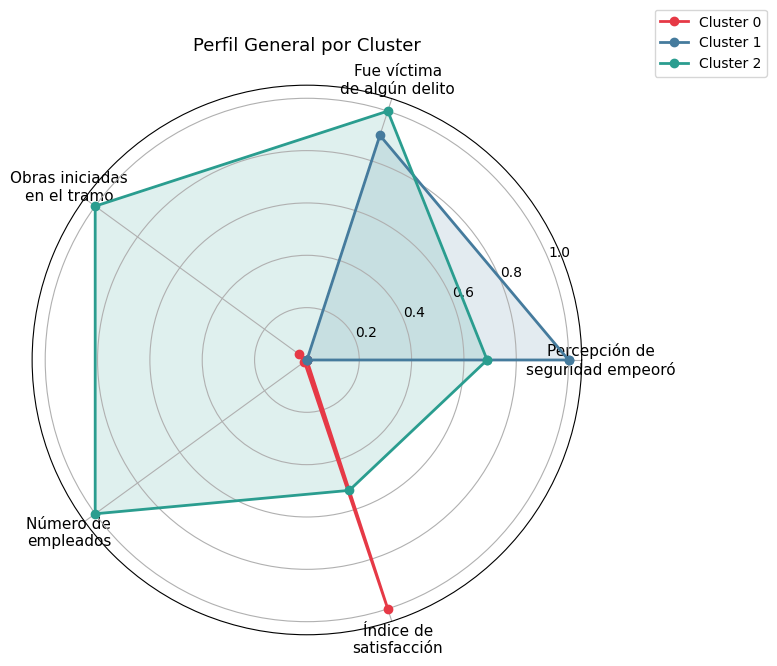

In [192]:
GENERAL_VARS = {
    "seguridad_empeoro":   "Percepción de\nseguridad empeoró",
    "fue_victima":         "Fue víctima\nde algún delito",
    "obras_iniciadas":     "Obras iniciadas\nen el tramo",
    "P1":                  "Número de\nempleados",
    "indice_satisfaccion": "Índice de\nsatisfacción",
}

seg_prof_gen = df_radar_corr.groupby("Cluster")[list(GENERAL_VARS.keys())].mean()
prof_norm_gen = seg_prof_gen.copy()
for col in GENERAL_VARS:
    mn, mx = seg_prof_gen[col].min(), seg_prof_gen[col].max()
    prof_norm_gen[col] = (seg_prof_gen[col] - mn) / (mx - mn) if mx > mn else 0.5

lbl_gen = list(GENERAL_VARS.values())
ang_gen = np.linspace(0, 2 * np.pi, len(lbl_gen), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for idx, (seg, row) in enumerate(prof_norm_gen.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    c = RADAR_COLORS[idx % len(RADAR_COLORS)]
    ax.plot(ang_gen, vals, "o-", linewidth=2, label=f"Cluster {seg}", color=c)
    ax.fill(ang_gen, vals, alpha=0.15, color=c)

ax.set_xticks(ang_gen[:-1])
ax.set_xticklabels(lbl_gen, fontsize=11)
ax.set_title("Perfil General por Cluster", pad=25, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()